In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [3]:
master = pd.read_csv("../data/constituency_master.csv")

df2021 = pd.read_csv("../data/tn_2021_results.csv")

df2026 = pd.read_csv("../data/tn_2026_results.csv")

df2026.head()

,constituency,ac_number,candidate,party,votes,turnout,reserved,region
0,Gummidipoondi,1,S.VIJAYAKUMAR,TVK,94320,NaN,GEN,Chennai Metro
1,Gummidipoondi,1,SUDHAKAR.V,AIADMK,66375,NaN,GEN,Chennai Metro
2,Gummidipoondi,1,T.J.GOVINDARAJAN,DMK,62492,NaN,GEN,Chennai Metro
3,Gummidipoondi,1,"R.SRIDAR. B.L.,",NTK,4756,NaN,GEN,Chennai Metro
4,Gummidipoondi,1,NOTA,NOTA,937,NaN,GEN,Chennai Metro


In [4]:
print(master.shape)
print(df2021.shape)
print(df2026.shape)

(234, 5)
(4232, 8)
(4257, 8)


In [5]:
df2021.columns
df2026.columns


Index(['constituency', 'ac_number', 'candidate', 'party', 'votes', 'turnout',
       'reserved', 'region'],
      dtype='object')

In [6]:
df2021.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4232 entries, 0 to 4231
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   constituency  4232 non-null   object 
 1   ac_number     4232 non-null   int64  
 2   candidate     4232 non-null   object 
 3   party         4232 non-null   object 
 4   votes         4232 non-null   int64  
 5   turnout       4232 non-null   float64
 6   reserved      4232 non-null   object 
 7   region        4232 non-null   object 
dtypes: float64(1), int64(2), object(5)
memory usage: 264.6+ KB


In [7]:
df2021.isnull().sum()
df2026.isnull().sum()


constituency       0
ac_number          0
candidate          0
party              0
votes              0
turnout         4257
reserved           0
region             0
dtype: int64

In [8]:
df2021.duplicated().sum()
df2026.duplicated().sum()

np.int64(0)

In [9]:
winner2021 = df2021.loc[
    df2021.groupby('ac_number')['votes'].idxmax()
]
winner2021.shape
winner2021.head()

,constituency,ac_number,candidate,party,votes,turnout,reserved,region
0,Gummidipundi,1,GOVINDARAJAN T.J,DMK,126452,78.08,GEN,Chennai Metro
13,Ponneri,2,DURAI. CHANDRASEKAR,INC,94528,78.20,SC,Chennai Metro
24,Tiruttani,3,S.Chandran,DMK,120314,78.76,GEN,Chennai Metro
39,Thiruvallur,4,"RAAJENDRAN, V.G.",DMK,107709,77.20,GEN,Chennai Metro
51,Poonamallee,5,Krishnaswamy A,DMK,149578,72.99,SC,Chennai Metro


In [10]:
winner2026 = df2026.loc[
    df2026.groupby('ac_number')['votes'].idxmax()
]
winner2026.shape
winner2026.head(20)

,constituency,ac_number,candidate,party,votes,turnout,reserved,region
0,Gummidipoondi,1,S.VIJAYAKUMAR,TVK,94320,NaN,GEN,Chennai Metro
16,Ponneri,2,DR.RAVI.M.S,TVK,110439,NaN,SC,Chennai Metro
30,Tiruttani,3,G.HARI,AIADMK,89169,NaN,GEN,Chennai Metro
44,Thiruvallur,4,DR. T. ARUNKUMAR,TVK,92190,NaN,GEN,Chennai Metro
59,Poonamallee,5,PRAKASAM.R,TVK,161309,NaN,SC,Chennai Metro
71,Avadi,6,R.RAMESH KUMAR,TVK,180384,NaN,GEN,Chennai Metro
92,Maduravoyal,7,RHEVANTH CHARAN,TVK,141725,NaN,GEN,Chennai Metro
114,Ambattur,8,BALAMURUGAN.G,TVK,133339,NaN,GEN,Chennai Metro
138,Madavaram,9,M.L.VIJAYPRABHU,TVK,190462,NaN,GEN,Chennai Metro
154,Thiruvottiyur,10,SENTHIL KUMAR. N,TVK,110067,NaN,GEN,Chennai Metro


In [11]:
winner2021['party'].value_counts()

party
DMK       133
AIADMK     66
INC        18
PMK         5
VCK         4
BJP         4
CPI         2
CPI(M)      2
Name: count, dtype: int64

In [12]:
winner2026['party'].value_counts()

party
TVK       108
DMK        59
AIADMK     47
INC         5
PMK         4
IUML        2
VCK         2
CPI         2
CPI(M)      2
BJP         1
DMDK        1
AMMK        1
Name: count, dtype: int64

In [13]:
winner2021_clean = winner2021[
    ['ac_number', 'constituency', 'candidate',
     'party', 'votes', 'region', 'reserved']
]
winner2021_clean.reset_index(drop=True, inplace=True)

In [14]:
winner2026_clean = winner2026[
    ['ac_number', 'constituency', 'candidate',
     'party', 'votes', 'region', 'reserved']
]
winner2026_clean.reset_index(drop=True, inplace=True)

In [15]:
winner2021_clean.to_csv("winner2021.csv", index=False)

winner2026_clean.to_csv("winner2026.csv", index=False)

In [16]:
winner2021_clean = winner2021_clean.rename(
    columns={'party': 'party_2021'}
)
winner2026_clean = winner2026_clean.rename(
    columns={'party': 'party_2026'}
)

In [17]:
flip_df = pd.merge(
    winner2021_clean[['ac_number', 'constituency', 'party_2021']],
    
    winner2026_clean[['ac_number', 'party_2026']],
    
    on='ac_number',
    
    how='inner'
)

In [18]:
flip_df['seat_flipped'] = (
    flip_df['party_2021']
    !=
    flip_df['party_2026']
)
flip_df['seat_flipped'].value_counts()

seat_flipped
True     163
False     71
Name: count, dtype: int64

In [19]:
flipped_seats = flip_df[
    flip_df['seat_flipped'] == True
]

In [20]:
flipped_seats.head()

,ac_number,constituency,party_2021,party_2026,seat_flipped
0,1,Gummidipundi,DMK,TVK,True
1,2,Ponneri,INC,TVK,True
2,3,Tiruttani,DMK,AIADMK,True
3,4,Thiruvallur,DMK,TVK,True
4,5,Poonamallee,DMK,TVK,True


In [21]:
flip_patterns = (
    flipped_seats
    .groupby(['party_2021', 'party_2026'])
    .size()
    .reset_index(name='count')
)

In [22]:
flip_patterns.sort_values(
    by='count',
    ascending=False
)

,party_2021,party_2026,count
13,DMK,TVK,65
3,AIADMK,TVK,26
8,DMK,AIADMK,22
0,AIADMK,DMK,15
17,INC,TVK,11
12,DMK,PMK,3
5,BJP,DMK,2
18,PMK,AIADMK,2
19,PMK,TVK,2
6,BJP,TVK,2


In [23]:
df2021_sorted = df2021.sort_values(
    ['ac_number', 'votes'],
    ascending=[True, False]
)
df2026_sorted = df2026.sort_values(
    ['ac_number', 'votes'],
    ascending=[True, False]
)

In [24]:
top2_2021 = (
    df2021_sorted
    .groupby('ac_number')
    .head(2)
)
top2_2026 = (
    df2026_sorted
    .groupby('ac_number')
    .head(2)
)

In [25]:
top2_2021['rank'] = (
    top2_2021
    .groupby('ac_number')
    .cumcount() + 1
)
top2_2026['rank'] = (
    top2_2026
    .groupby('ac_number')
    .cumcount() + 1
)

C:\Users\vidhi\AppData\Local\Temp\ipykernel_61764\107885807.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top2_2021['rank'] = (
C:\Users\vidhi\AppData\Local\Temp\ipykernel_61764\107885807.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top2_2026['rank'] = (


In [26]:
winner_2021 = top2_2021[
    top2_2021['rank'] == 1
]
runnerup_2021 = top2_2021[
    top2_2021['rank'] == 2
]

In [27]:
winner_2026 = top2_2026[
    top2_2026['rank'] == 1
]
runnerup_2026 = top2_2026[
    top2_2026['rank'] == 2
]

In [28]:
margin2021 = pd.merge(
    winner_2021[['ac_number', 'constituency', 'votes']],
    
    runnerup_2021[['ac_number', 'votes']],
    
    on='ac_number',
    
    suffixes=('_winner', '_runnerup')
)

In [29]:
margin2021['margin'] = (
    margin2021['votes_winner']
    -
    margin2021['votes_runnerup']
)

In [30]:
margin2021['margin'].describe()

count       234.000000
mean      22870.547009
std       19845.530251
min         137.000000
25%        8517.000000
50%       19131.000000
75%       30760.250000
max      135571.000000
Name: margin, dtype: float64

In [31]:
margin2026 = pd.merge(
    winner_2026[['ac_number', 'constituency', 'votes']],
    
    runnerup_2026[['ac_number', 'votes']],
    
    on='ac_number',
    
    suffixes=('_winner', '_runnerup')
)
margin2026['margin'] = (
    margin2026['votes_winner']
    -
    margin2026['votes_runnerup']
)

In [32]:
margin2026['margin'].describe()

count      234.000000
mean     16784.243590
std      17988.471906
min          1.000000
25%       4808.000000
50%      11415.500000
75%      21292.500000
max      98110.000000
Name: margin, dtype: float64

In [33]:
region_2021 = (
    winner2021_clean
    .groupby(['region', 'party_2021'])
    .size()
    .reset_index(name='seats_2021')
)
region_2021.head(20)

,region,party_2021,seats_2021
0,Central,AIADMK,15
1,Central,DMK,21
2,Central,INC,1
3,Central,PMK,3
4,Central,VCK,1
5,Chennai Metro,DMK,29
6,Chennai Metro,INC,3
7,Delta,AIADMK,4
8,Delta,CPI,1
9,Delta,CPI(M),2


In [34]:
region_2026 = (
    winner2026_clean
    .groupby(['region', 'party_2026'])
    .size()
    .reset_index(name='seats_2026')
)
region_2026.head(20)

,region,party_2026,seats_2026
0,Central,AIADMK,15
1,Central,DMDK,1
2,Central,DMK,8
3,Central,PMK,3
4,Central,TVK,12
5,Central,VCK,2
6,Chennai Metro,AIADMK,1
7,Chennai Metro,DMK,2
8,Chennai Metro,TVK,29
9,Delta,AIADMK,4


In [35]:
region_compare = pd.merge(
    region_2021,
    region_2026,
    
    left_on=['region', 'party_2021'],
    right_on=['region', 'party_2026'],
    
    how='outer'
)
region_compare = region_compare.fillna(0)

In [36]:
region_compare['seat_change'] = (
    region_compare['seats_2026']
    -
    region_compare['seats_2021']
)

In [37]:
region_compare.sort_values(
    by='seat_change',
    ascending=False
)

,region,party_2021,seats_2021,party_2026,seats_2026,seat_change
10,Chennai Metro,0,0.0,TVK,29.0,29.0
38,South,0,0.0,TVK,26.0,26.0
24,Kongu,0,0.0,TVK,16.0,16.0
31,North,0,0.0,TVK,15.0,15.0
5,Central,0,0.0,TVK,12.0,12.0
18,Delta,0,0.0,TVK,10.0,10.0
25,North,AIADMK,12.0,AIADMK,15.0,3.0
17,Delta,0,0.0,IUML,1.0,1.0
29,North,0,0.0,IUML,1.0,1.0
35,South,0,0.0,CPI(M),1.0,1.0


In [38]:
total_flips = flipped_seats.shape[0]

flip_percentage = (
    total_flips / 234
) * 100

print(flip_percentage)

69.65811965811966


In [39]:
closest_seats_2026 = margin2026.sort_values(
    by='margin'
)
closest_seats_2026.head(10)

,ac_number,constituency,votes_winner,votes_runnerup,margin
184,185,Tiruppattur,83375,83374,1
53,54,Veppanahalli,74691,74553,138
228,229,Kanniyakumari,75045,74831,214
65,66,Polur,67961,67734,227
75,76,Tirukkoyilur,73033,72748,285
94,95,Paramathi-Velur,61349,61041,308
136,137,Kulithalai,68138,67559,579
170,171,Kumbakonam,78650,77971,679
126,127,Palani,66986,66293,693
71,72,Tindivanam,63833,63099,734


In [40]:
largest_margins_2026 = margin2026.sort_values(
    by='margin',
    ascending=False
)
largest_margins_2026.head(10)

,ac_number,constituency,votes_winner,votes_runnerup,margin
85,86,Edappadi,148933,50823,98110
26,27,Shozhinganallur,220382,123602,96780
8,9,Madavaram,190462,95477,94985
5,6,Avadi,180384,104073,76311
87,88,Salem (West),120407,45540,74867
4,5,Poonamallee,161309,88569,72740
112,113,Tiruppur (North),131401,61409,69992
178,179,Viralimalai,105773,43700,62073
6,7,Maduravoyal,141725,80216,61509
7,8,Ambattur,133339,74558,58781


In [41]:
flip_region = pd.merge(
    flipped_seats,
    
    master[['ac_number', 'region']],
    
    on='ac_number',
    
    how='left'
)

In [42]:
region_flip_count = (
    flip_region
    .groupby('region')
    .size()
    .reset_index(name='flip_count')
)
region_flip_count.sort_values(
    by='flip_count',
    ascending=False
)

,region,flip_count
5,South,38
1,Chennai Metro,30
4,North,27
3,Kongu,27
0,Central,26
2,Delta,15


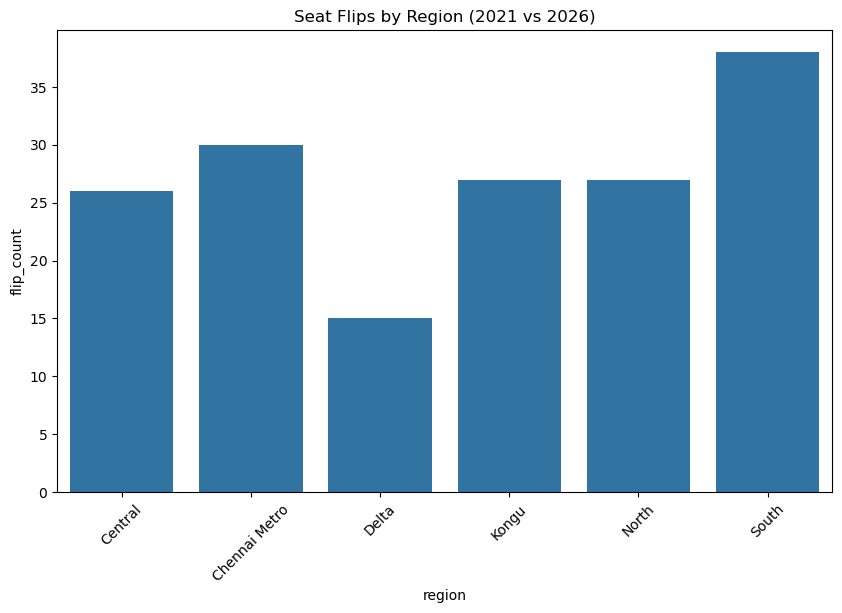

In [43]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=region_flip_count,
    x='region',
    y='flip_count'
)

plt.title('Seat Flips by Region (2021 vs 2026)')

plt.xticks(rotation=45)

plt.show()

In [44]:
avg_margin = pd.DataFrame({
    'Year': ['2021', '2026'],
    
    'Average Margin': [
        margin2021['margin'].mean(),
        margin2026['margin'].mean()
    ]
})

avg_margin

,Year,Average Margin
0,2021,22870.547009
1,2026,16784.243590


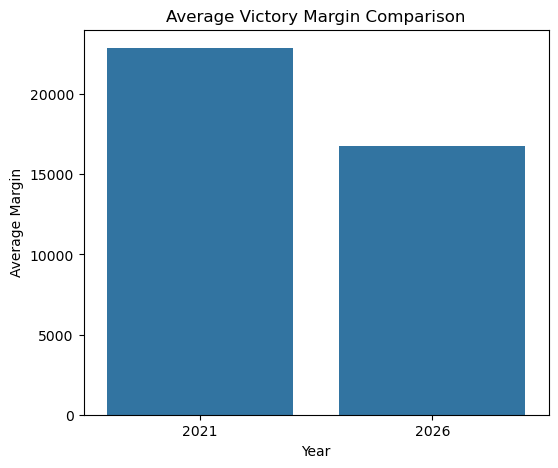

In [45]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=avg_margin,
    x='Year',
    y='Average Margin'
)

plt.title('Average Victory Margin Comparison')

plt.show()

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

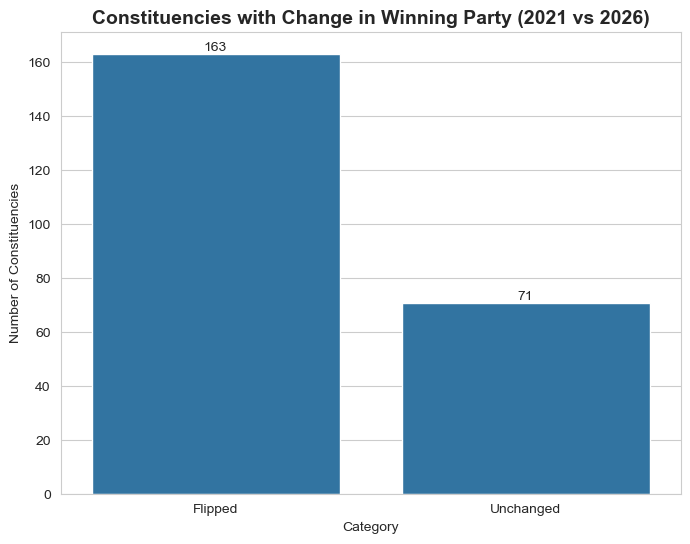

In [47]:
flip_summary = pd.DataFrame({
    'Category': ['Flipped', 'Unchanged'],
    'Seats': [
        flipped_seats.shape[0],
        234 - flipped_seats.shape[0]
    ]
})

plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=flip_summary,
    x='Category',
    y='Seats'
)

plt.title(
    'Constituencies with Change in Winning Party (2021 vs 2026)',
    fontsize=14,
    weight='bold'
)

plt.ylabel('Number of Constituencies')

for i in ax.containers:
    ax.bar_label(i)

plt.show()

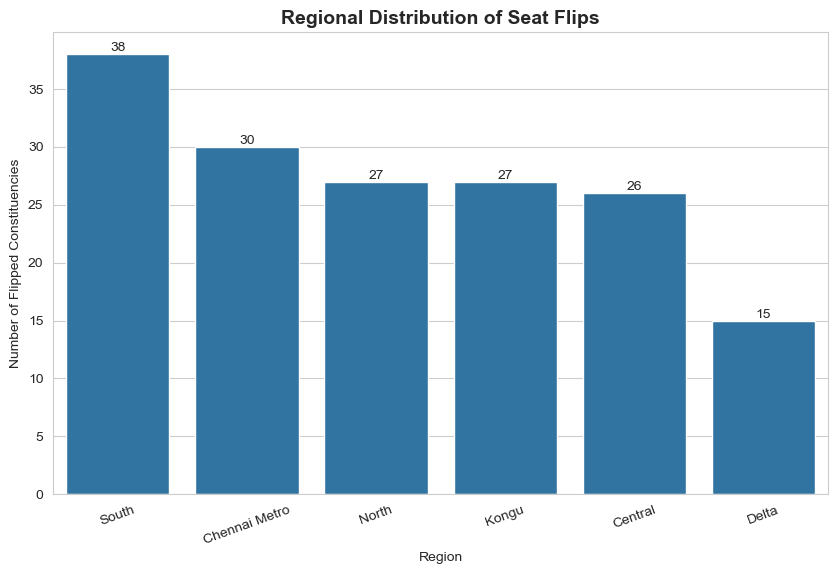

In [48]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=region_flip_count.sort_values(
        by='flip_count',
        ascending=False
    ),
    
    x='region',
    y='flip_count'
)

plt.title(
    'Regional Distribution of Seat Flips',
    fontsize=14,
    weight='bold'
)

plt.xlabel('Region')
plt.ylabel('Number of Flipped Constituencies')

plt.xticks(rotation=20)

for i in ax.containers:
    ax.bar_label(i)

plt.show()

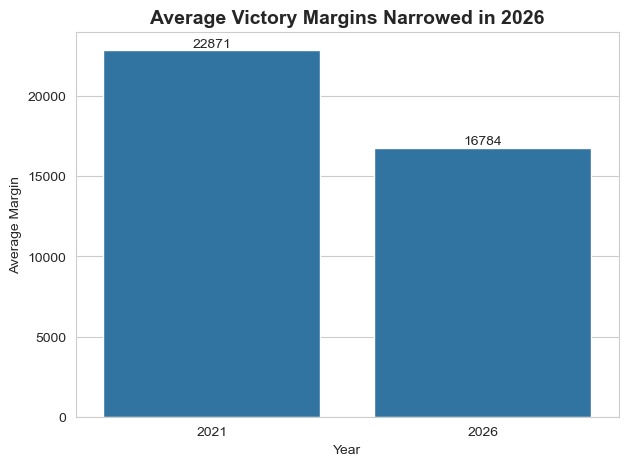

In [49]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=avg_margin,
    x='Year',
    y='Average Margin'
)

plt.title(
    'Average Victory Margins Narrowed in 2026',
    fontsize=14,
    weight='bold'
)

plt.ylabel('Average Margin')

for i in ax.containers:
    ax.bar_label(i, fmt='%.0f')

plt.show()

In [50]:
top_close = closest_seats_2026.head(10)

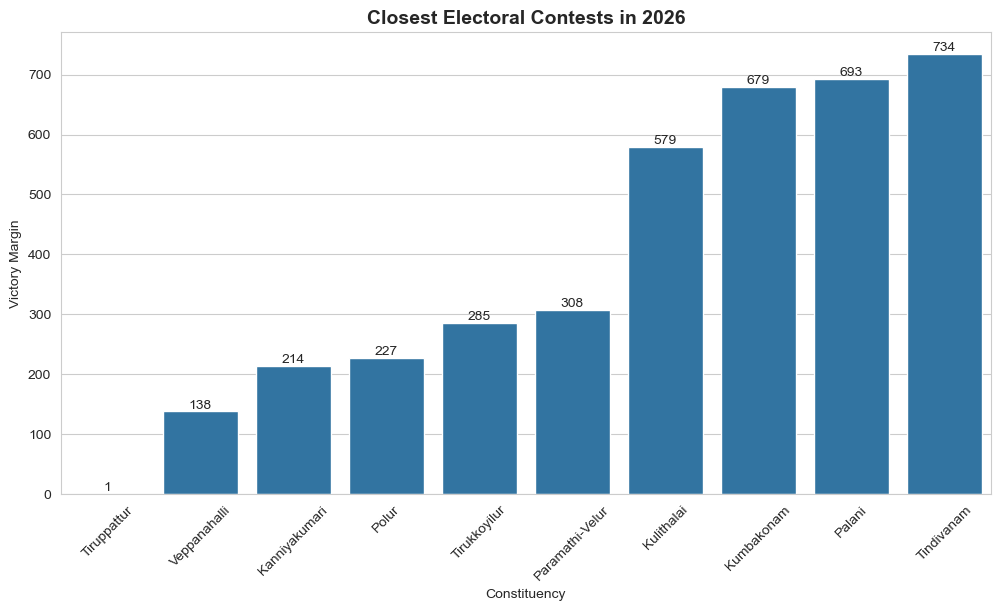

In [51]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_close,
    x='constituency',
    y='margin'
)

plt.title(
    'Closest Electoral Contests in 2026',
    fontsize=14,
    weight='bold'
)

plt.xlabel('Constituency')
plt.ylabel('Victory Margin')

plt.xticks(rotation=45)

for i in ax.containers:
    ax.bar_label(i)

plt.show()

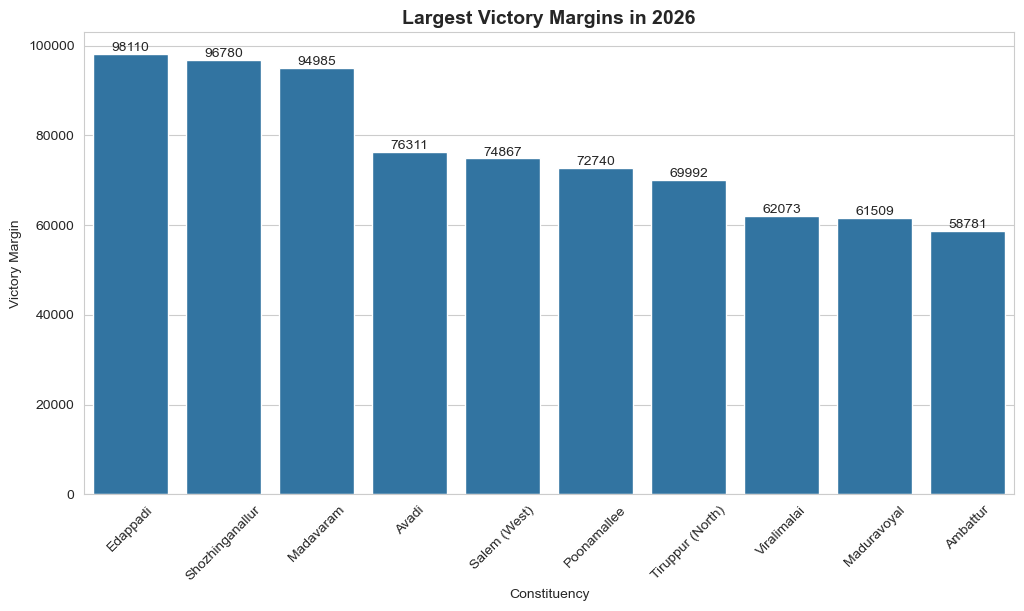

In [52]:
top_landslides = largest_margins_2026.head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_landslides,
    x='constituency',
    y='margin'
)

plt.title(
    'Largest Victory Margins in 2026',
    fontsize=14,
    weight='bold'
)

plt.xlabel('Constituency')
plt.ylabel('Victory Margin')

plt.xticks(rotation=45)

for i in ax.containers:
    ax.bar_label(i)

plt.show()

In [53]:
sankey_df = flip_patterns[
    flip_patterns['party_2021']
    !=
    flip_patterns['party_2026']
]

In [54]:
sankey_df = sankey_df.sort_values(
    by='count',
    ascending=False
)

In [55]:
sankey_df.head(10)

,party_2021,party_2026,count
13,DMK,TVK,65
3,AIADMK,TVK,26
8,DMK,AIADMK,22
0,AIADMK,DMK,15
17,INC,TVK,11
12,DMK,PMK,3
5,BJP,DMK,2
18,PMK,AIADMK,2
19,PMK,TVK,2
6,BJP,TVK,2


In [56]:
sankey_df = flip_patterns[
    flip_patterns['party_2021']
    !=
    flip_patterns['party_2026']
]
sankey_df = sankey_df.sort_values(
    by='count',
    ascending=False
)
sankey_df.head(10)

,party_2021,party_2026,count
13,DMK,TVK,65
3,AIADMK,TVK,26
8,DMK,AIADMK,22
0,AIADMK,DMK,15
17,INC,TVK,11
12,DMK,PMK,3
5,BJP,DMK,2
18,PMK,AIADMK,2
19,PMK,TVK,2
6,BJP,TVK,2


In [57]:
sankey_df.to_csv(
    "sankey_dataset.csv",
    index=False
)

In [58]:
region_flip_count.to_csv("region_flip_count.csv", index=False)

margin2026.to_csv("margin2026.csv", index=False)

avg_margin.to_csv("avg_margin.csv", index=False)

In [59]:
winner2021_party = (
    winner2021['party']
    .value_counts()
    .reset_index()
)

winner2021_party.columns = ['party','seats_2021']

winner2026_party = (
    winner2026['party']
    .value_counts()
    .reset_index()
)

winner2026_party.columns = ['party','seats_2026']

party_compare = winner2021_party.merge(
    winner2026_party,
    on='party',
    how='outer'
).fillna(0)

party_compare.to_csv(
    'party_compare.csv',
    index=False
)

party_compare.head()

,party,seats_2021,seats_2026
0,AIADMK,66.0,47
1,AMMK,0.0,1
2,BJP,4.0,1
3,CPI,2.0,2
4,CPI(M),2.0,2
